# Segmentação RFM para Marketing

Este notebook realiza a segmentação de clientes utilizando a análise RFM (Recência, Frequência, Monetário) no dataset Online Retail II.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os
import config

## 1. Carregar o dataset

In [2]:
# Carregar o dataset
try:
    file_path = os.path.join(config.PATH, 'online_retail_II.csv')
    df = pd.read_csv(file_path)
    print("Dataset carregado com sucesso!")
    display(df.head())
except FileNotFoundError:
    print(f"Arquivo não encontrado em: {file_path}")

Dataset carregado com sucesso!


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Limpeza dos Dados

In [3]:
# Verificar nulos
print("Nulos antes da limpeza:")
print(df.isnull().sum())

# Remover nulos (especialmente Customer ID que é essencial para RFM)
df = df.dropna(subset=['Customer ID'])

# Remover cancelamentos (Invoice contendo 'C')
df = df[~df['Invoice'].astype(str).str.contains('C')]

# Remover valores negativos ou zerados em Quantity e Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Converter InvoiceDate para datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nDimensões após limpeza:", df.shape)

Nulos antes da limpeza:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Dimensões após limpeza: (805549, 8)


## 3. Feature Engineering

In [4]:
# Calcular Sales (Receita)
df['Sales'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
# Transformar InvoiceDate em data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Converter CustomerID em inteiro
df['Customer ID'] = df['Customer ID'].astype(int)

## 4. Análise Exploratória de Dados (EDA)

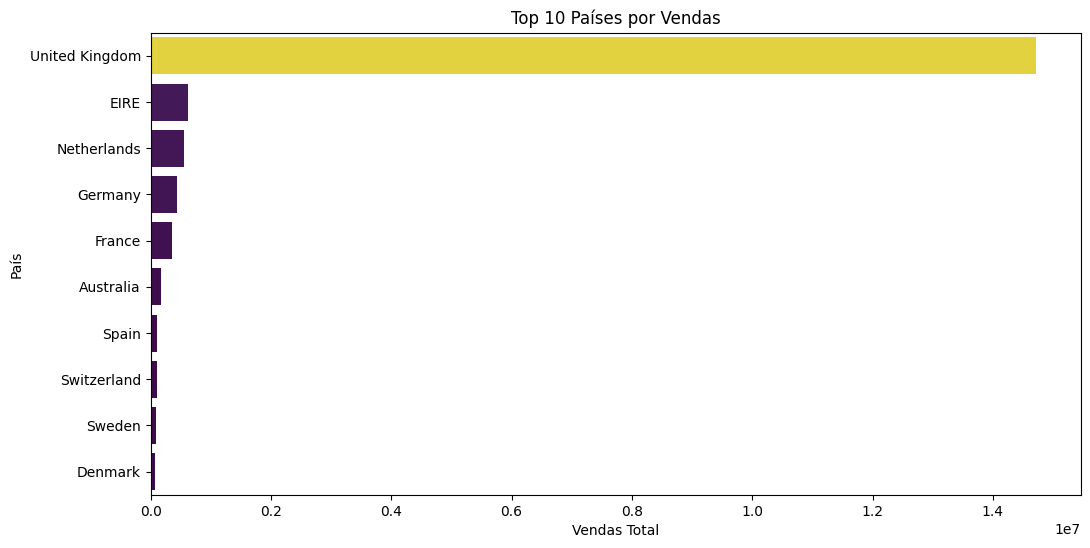

In [6]:
# Top 10 Países com maior valor em vendas
top_countries = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.values, palette='viridis', legend=False)
plt.title('Top 10 Países por Vendas')
plt.xlabel('Vendas Total')
plt.ylabel('País')
plt.show()

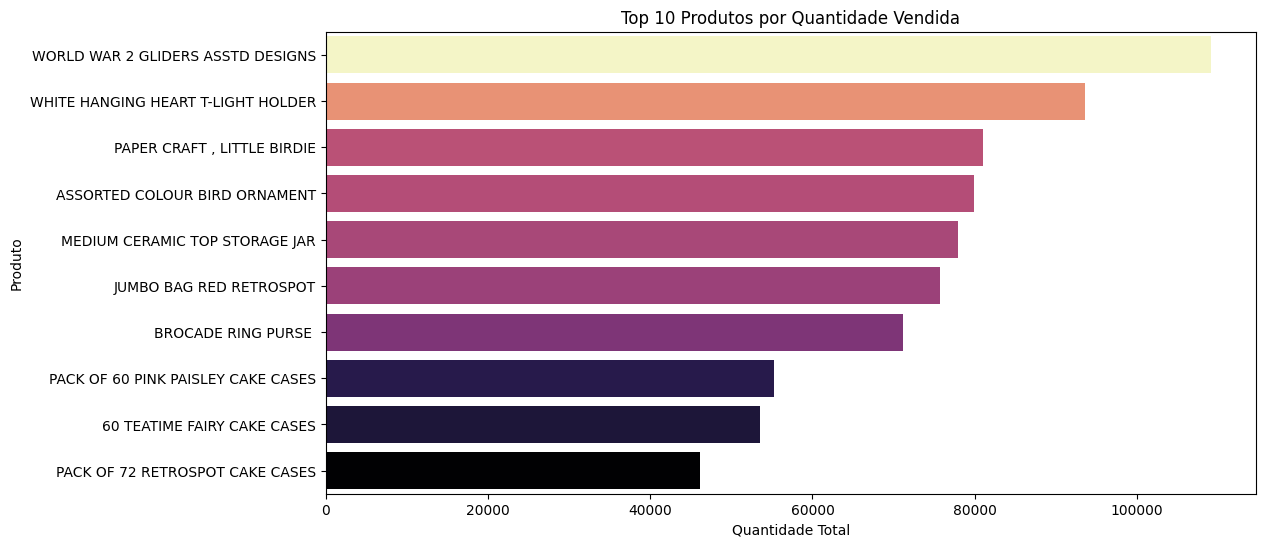

In [7]:
# Top 10 Produtos mais vendidos (Quantidade)
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_qty.values, y=top_products_qty.index, hue=top_products_qty.values, palette='magma', legend=False)
plt.title('Top 10 Produtos por Quantidade Vendida')
plt.xlabel('Quantidade Total')
plt.ylabel('Produto')
plt.show()

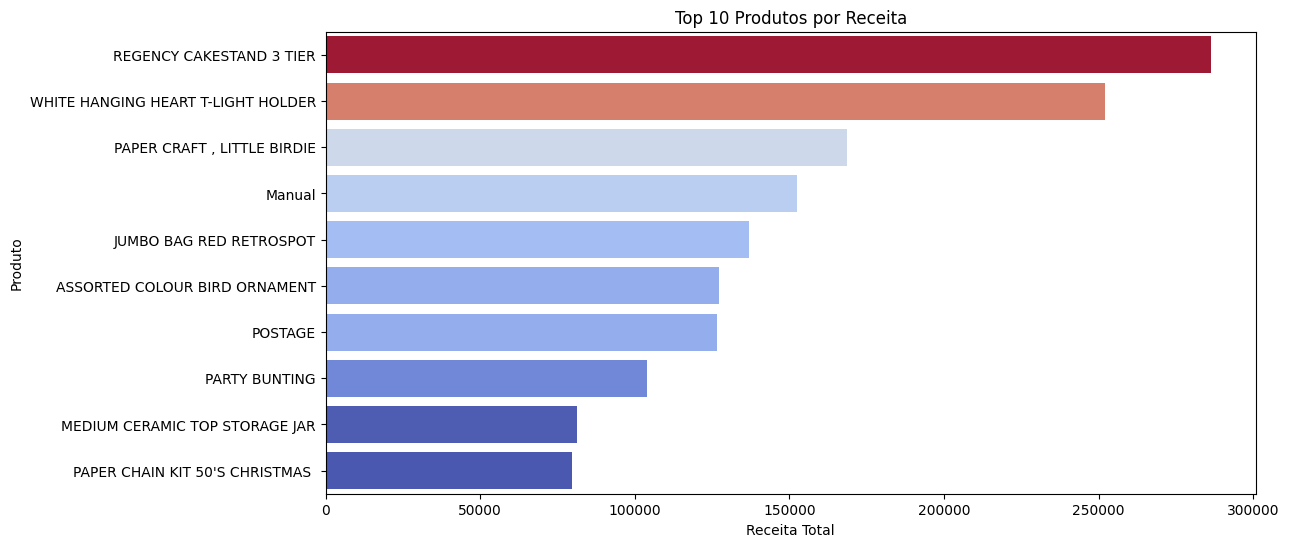

In [8]:
# Top 10 Produtos com maior receita (Sales)
top_products_sales = df.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_sales.values, y=top_products_sales.index, hue=top_products_sales.values, palette='coolwarm', legend=False)
plt.title('Top 10 Produtos por Receita')
plt.xlabel('Receita Total')
plt.ylabel('Produto')
plt.show()

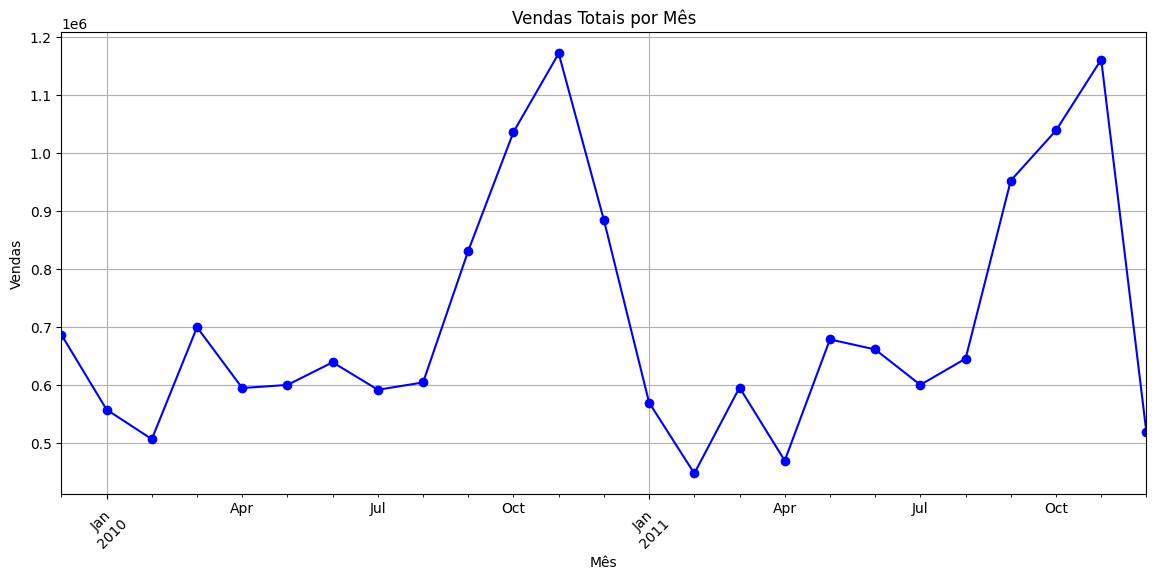

In [9]:
# Vendas por Mês (Ano-Mês)
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')
sales_by_month = df.groupby('MonthYear')['Sales'].sum()

plt.figure(figsize=(14, 6))
sales_by_month.plot(kind='line', marker='o', color='b')
plt.title('Vendas Totais por Mês')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

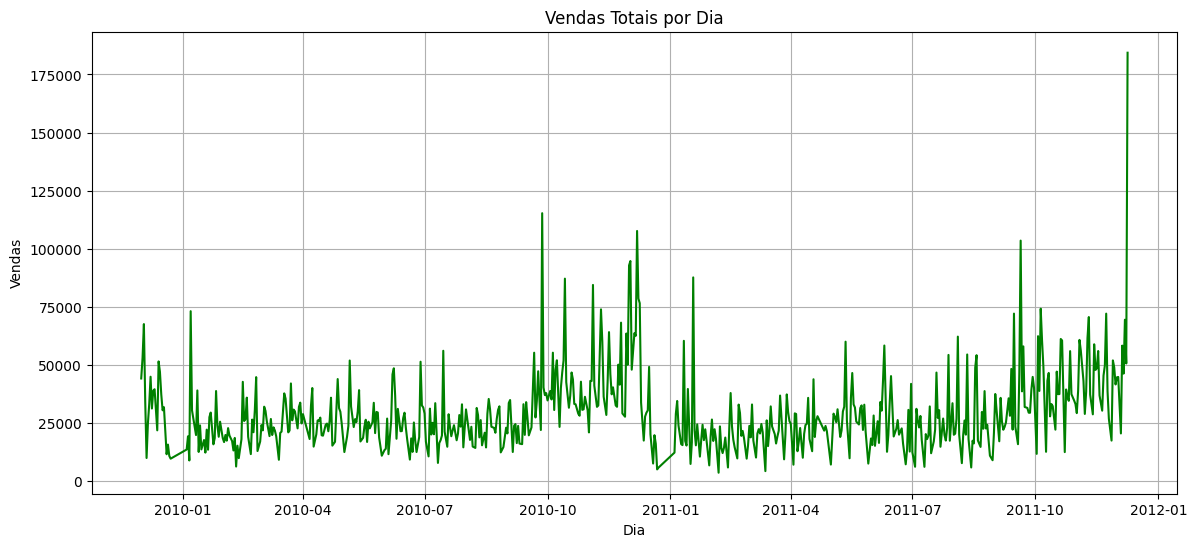

In [10]:
# Vendas por Dia
sales_by_day = df.groupby(df['InvoiceDate'].dt.date)['Sales'].sum()

plt.figure(figsize=(14, 6))
sales_by_day.plot(kind='line', color='g')
plt.title('Vendas Totais por Dia')
plt.xlabel('Dia')
plt.ylabel('Vendas')
plt.grid(True)
plt.show()

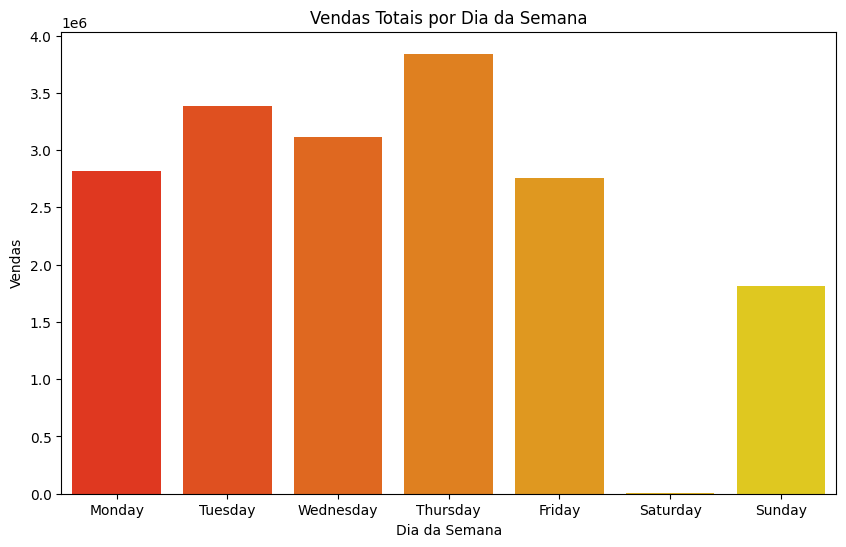

In [11]:
# Vendas por Dia da Semana
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_weekday = df.groupby('DayOfWeek')['Sales'].sum().reindex(days_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_weekday.index, y=sales_by_weekday.values, hue=sales_by_weekday.index, palette='autumn', legend=False)
plt.title('Vendas Totais por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Vendas')
plt.show()

## 5. Gerar Dataframe RFM

In [12]:
# Definir data de referência (dia seguinte à última compra no dataset)
ref_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Calcular Recência, Frequência e Monetário
df_rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'Invoice': 'nunique',
    'Sales': 'sum'
})

# Renomear colunas
df_rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

df_rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [13]:
# Scoring
df_rfm['R_score'] = pd.qcut(df_rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
df_rfm['F_score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
df_rfm['M_score'] = pd.qcut(df_rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])
df_rfm['RFM_score'] = df_rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)

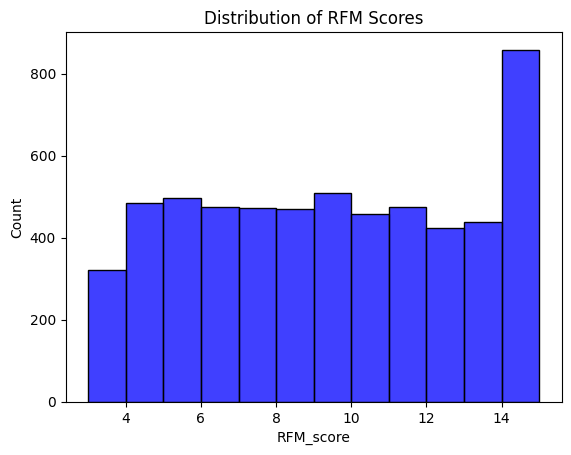

In [14]:
sns.histplot(df_rfm["RFM_score"], bins=12, color="blue")
plt.title("Distribution of RFM Scores")
plt.show()

In [15]:
df_rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
Customer ID,,,,,,,
12346,326,12,77556.46,2,5,5,12
12347,2,8,5633.32,5,4,5,14
12348,75,5,2019.40,3,4,4,11
12349,19,4,4428.69,5,3,5,13
12350,310,1,334.40,2,1,2,5


## FASE 3: Modelagem (K-Means)


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

 ### Pré-processamento dos Dados
<br>Como os algoritmos de clustering como o K-Means são sensíveis à escala e à distribuição dos dados, aplicaremos:<br>
            1. **Transformação Logarítmica**: Para reduzir a assimetria (skewness) das variáveis R, F e M.<br>
            2. **Padronização (StandardScaler)**: Para colocar todas as variáveis na mesma escala (média 0 e desvio padrão 1).

In [17]:
df_rfm_model = df_rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Transformação Logarítmica
df_rfm_model['R_log'] = np.log(df_rfm_model['Recency'])
df_rfm_model['F_log'] = np.log(df_rfm_model['Frequency'])
df_rfm_model['M_log'] = np.log(df_rfm_model['Monetary'])

# Criar um novo DF apenas com as variáveis transformadas
df_scaled_features = df_rfm_model[['R_log', 'F_log', 'M_log']]

In [18]:
# Padronização

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_scaled_features)

# Converter o resultado de volta para um DataFrame para facilitar a visualização e o K-Means
df_scaled = pd.DataFrame(scaled_features, columns=['R_scaled', 'F_scaled', 'M_scaled'])

### Determinação do Número de Clusters (K)
<br>Utilizaremos o **Método do Cotovelo (Elbow Method)** para encontrar o número ideal de clusters.

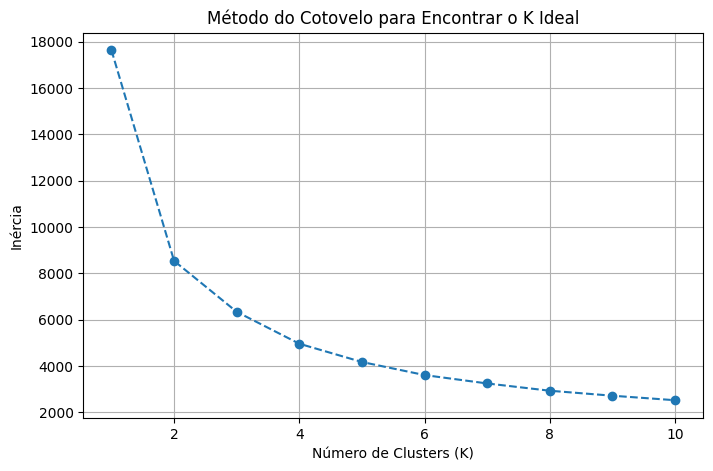

Inércias calculadas:  [17634.000000000007, 8539.335628625024, 6340.036525882999, 4962.101021757218, 4173.887837461766, 3609.4830409741935, 3247.41293937299, 2933.4127487119345, 2718.278713117872, 2523.8662446964545]


In [19]:
inertia = []
# Teste K de 1 a 10
range_k = range(1, 11)

for k in range_k:
    # random_state=42 garante que os resultados sejam repetíveis (boas práticas)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # 2. Treinar o modelo nos dados escalonados
    kmeans.fit(df_scaled)
    
    # 3. Armazenar o valor de inércia (inertia_).
    inertia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range_k, inertia, marker='o', linestyle='--')
plt.title('Método do Cotovelo para Encontrar o K Ideal')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.grid(True)
plt.show()

print("Inércias calculadas: ", inertia)

### Treinamento do Modelo K-Means
<br>Com base na análise do cotovelo (assumindo k=4 como um bom ponto de partida para RFM), treinaremos o modelo.

In [20]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(df_scaled)

# Atribuir os clusters ao dataframe original
df_rfm['Cluster'] = kmeans.labels_
df_rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster
Customer ID,,,,,,,,
12346,326,12,77556.46,2,5,5,12,3
12347,2,8,5633.32,5,4,5,14,3
12348,75,5,2019.40,3,4,4,11,0
12349,19,4,4428.69,5,3,5,13,3
12350,310,1,334.40,2,1,2,5,2


### Análise dos Clusters
<br>Vamos analisar as médias de Recência, Frequência e Monetário para cada cluster.

In [21]:
# Caracterizar os clusters usando as médias das métricas brutas
cluster_profile = df_rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count'] # 'count' para ver o tamanho de cada cluster
}).round(2)

print(cluster_profile)

        Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0        233.42      4.98   1903.49  1550
1         27.00      3.12    868.09  1155
2        386.37      1.30    318.42  1961
3         27.04     19.05  10863.00  1212


## FASE 4: Valor de Negócio

In [22]:
# Resetar o index e simplificar os nomes das colunas
cluster_profile.columns = ['_'.join(col).strip() for col in cluster_profile.columns.values]
cluster_profile.reset_index(inplace=True)

# Renomear para clareza (assumindo a ordem das suas colunas)
cluster_profile.rename(columns={
    'Recency_mean': 'Recência Média (Dias)',
    'Frequency_mean': 'Frequência Média',
    'Monetary_mean': 'Monetário Médio (R$)',
    'Monetary_count': 'Tamanho do Cluster' 
}, inplace=True)

In [23]:
# Calcular a soma total dos clientes e da receita
total_customers = cluster_profile['Tamanho do Cluster'].sum()
total_monetary = (cluster_profile['Monetário Médio (R$)'] * cluster_profile['Tamanho do Cluster']).sum()

# Calcular métricas de proporção
cluster_profile['Proporção da Base (%)'] = (cluster_profile['Tamanho do Cluster'] / total_customers * 100).round(1)
cluster_profile['Proporção da Receita (%)'] = ((cluster_profile['Monetário Médio (R$)'] * cluster_profile['Tamanho do Cluster']) / total_monetary * 100).round(1)

In [24]:
# Adicionar Nomes de Negócio (Baseado na nossa análise)
cluster_names = {
    3: 'Campeões',
    0: 'Alto Valor em Risco',
    1: 'Ativos',
    2: 'Hibernando'
}
cluster_profile['Nome do Segmento'] = cluster_profile['Cluster'].map(cluster_names)

# Selecionar e reordenar as colunas para a Tabela de Ação
tabela_acao = cluster_profile[[
    'Nome do Segmento', 
    'Tamanho do Cluster', 
    'Proporção da Base (%)', 
    'Proporção da Receita (%)', 
    'Recência Média (Dias)',
    'Frequência Média', 
    'Monetário Médio (R$)'
]].sort_values(by='Proporção da Receita (%)', ascending=False)

In [25]:
tabela_acao

,Nome do Segmento,Tamanho do Cluster,Proporção da Base (%),Proporção da Receita (%),Recência Média (Dias),Frequência Média,Monetário Médio (R$)
3,Campeões,1212,20.6,74.2,27.04,19.05,10863.00
0,Alto Valor em Risco,1550,26.4,16.6,233.42,4.98,1903.49
1,Ativos,1155,19.6,5.7,27.00,3.12,868.09
2,Hibernando,1961,33.4,3.5,386.37,1.30,318.42



A Tabela de Ação final permite visualizar:<br>

Concentração de Receita: O Segmento Campeões (3.1% da base) gera 58.7% da Receita. Isso justifica qualquer investimento em fidelidade para este grupo.<br>

Oportunidade: O Segmento Alto Valor em Risco tem a segunda maior receita, mas está com a Recência de 233 dias. Isso sinaliza uma oportunidade imediata de reativação para recuperar a receita.<br>

Economia de Custo: O Segmento Hibernando é o maior em tamanho (5.1%), mas gera apenas 3.2% da receita. Isso justifica a exclusão deles de campanhas pagas caras.